### Section 1: Install Required Libraries and Load Dataset

**1.1: Install Required Libraries and Import Dependencies**

In [3]:
# Import required libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import KMeans, DBSCAN, MeanShift, AgglomerativeClustering
import hdbscan
from sklearn.manifold import TSNE
from sklearn.cluster import SpectralClustering

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)


**1.2: Load and Inspect the Dataset**

In [4]:
# Load Dataset
from ucimlrepo import fetch_ucirepo

# Fetch dataset
wine_quality = fetch_ucirepo(id=186)

# Extract features and target
X = wine_quality.data.features
y = wine_quality.data.targets

# Display metadata and variable information
print("Metadata:")
print(wine_quality.metadata)

print("\nVariable Information:")
print(wine_quality.variables)

# Inspect the first few rows of the dataset
print("\nFeature Data (X):")
print(X.head())

print("\nTarget Data (y):")
print(y.head())

Metadata:
{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine p

### Section 2: Preprocess the Data

In [5]:
# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Confirm the preprocessing
print("Features after normalization:")
print(X_scaled[:5])

Features after normalization:
[[ 0.14247327  2.18883292 -2.19283252 -0.7447781   0.56995782 -1.10013986
  -1.44635852  1.03499282  1.81308951  0.19309677 -0.91546416]
 [ 0.45103572  3.28223494 -2.19283252 -0.59764007  1.1979747  -0.31132009
  -0.86246863  0.70148631 -0.11507303  0.99957862 -0.58006813]
 [ 0.45103572  2.55330026 -1.91755268 -0.66069923  1.02669737 -0.87476278
  -1.09248586  0.76818761  0.25811972  0.79795816 -0.58006813]
 [ 3.07381662 -0.36243847  1.66108525 -0.7447781   0.54141159 -0.76207424
  -0.98632406  1.10169412 -0.3638682   0.32751041 -0.58006813]
 [ 0.14247327  2.18883292 -2.19283252 -0.7447781   0.56995782 -1.10013986
  -1.44635852  1.03499282  1.81308951  0.19309677 -0.91546416]]


### Section 3: Metrics And Visualizations

In [6]:
# Initialize results dictionary
results = {
    "Algorithm": [],
    "Silhouette Score": [],
    "Davies-Bouldin Index": [],
    "Calinski-Harabasz Score": []
}

# Function to compute and print clustering metrics
def compute_metrics(X_scaled, labels, algorithm_name):
    silhouette = silhouette_score(X_scaled, labels)
    davies_bouldin = davies_bouldin_score(X_scaled, labels)
    calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
    print(f"{algorithm_name} Metrics:")
    print(f"  Silhouette Score: {silhouette}")
    print(f"  Davies-Bouldin Index: {davies_bouldin}")
    print(f"  Calinski-Harabasz Score: {calinski_harabasz}")
    return silhouette, davies_bouldin, calinski_harabasz

# Function to visualize clustering using PCA
def visualize_clusters_pca(X_scaled, labels, algorithm_name):
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=10)
    plt.title(f"{algorithm_name} Clustering Visualization (PCA)")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.colorbar()
    plt.show()

# Function to visualize clustering using t-SNE
def visualize_clusters_tsne(X_scaled, labels, algorithm_name):
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    X_tsne = tsne.fit_transform(X_scaled)
    plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='viridis', s=10)
    plt.title(f"{algorithm_name} Clustering Visualization (t-SNE)")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.colorbar()
    plt.show()

### Section 4: Clustering Algorithms And Compute Metrics & Visualize

**4.1: K-Means Clustering**

K-Means Metrics:
  Silhouette Score: 0.23507051305631002
  Davies-Bouldin Index: 1.4840341315918062
  Calinski-Harabasz Score: 1844.4573389218715


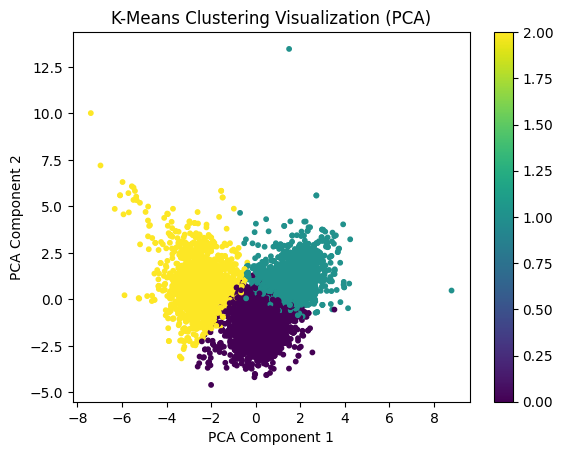

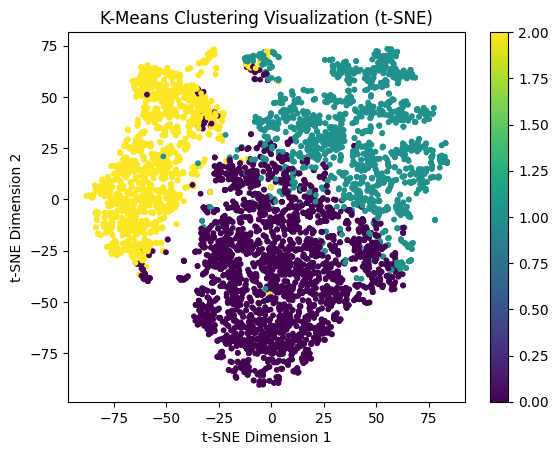

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Compute metrics and visualize
silhouette, davies_bouldin, calinski_harabasz = compute_metrics(X_scaled, kmeans_labels, "K-Means")
visualize_clusters_pca(X_scaled, kmeans_labels, "K-Means")
visualize_clusters_tsne(X_scaled, kmeans_labels, "K-Means")

results["Algorithm"].append("K-Means")
results["Silhouette Score"].append(silhouette)
results["Davies-Bouldin Index"].append(davies_bouldin)
results["Calinski-Harabasz Score"].append(calinski_harabasz)

**4.2: DBSCAN Clustering**

DBSCAN Metrics:
  Silhouette Score: -0.4526705197482366
  Davies-Bouldin Index: 1.1565209679156763
  Calinski-Harabasz Score: 5.852492806901058


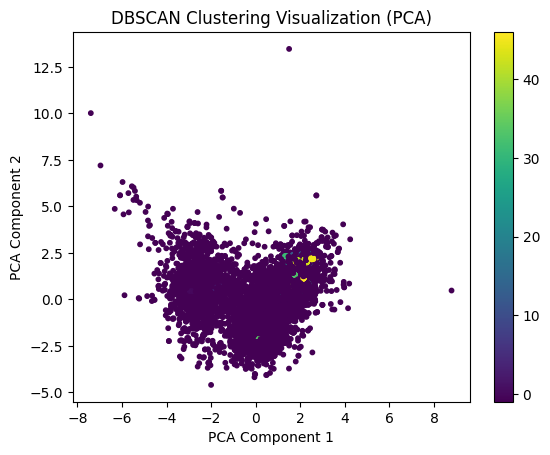

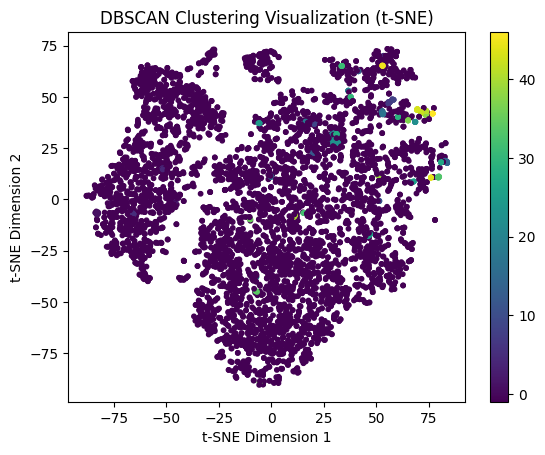

In [8]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Compute metrics and visualize
silhouette, davies_bouldin, calinski_harabasz = compute_metrics(X_scaled, dbscan_labels, "DBSCAN")
visualize_clusters_pca(X_scaled, dbscan_labels, "DBSCAN")
visualize_clusters_tsne(X_scaled, dbscan_labels, "DBSCAN")

results["Algorithm"].append("DBSCAN")
results["Silhouette Score"].append(silhouette)
results["Davies-Bouldin Index"].append(davies_bouldin)
results["Calinski-Harabasz Score"].append(calinski_harabasz)

**4.3: HDBSCAN Clustering**

HDBSCAN Metrics:
  Silhouette Score: 0.5457404063730977
  Davies-Bouldin Index: 1.7619696978052346
  Calinski-Harabasz Score: 136.8522309228647


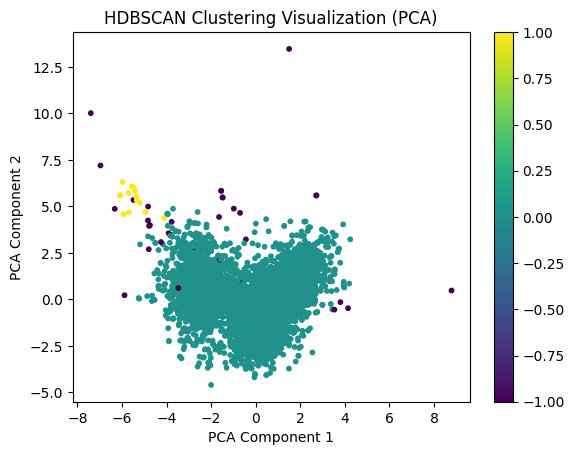

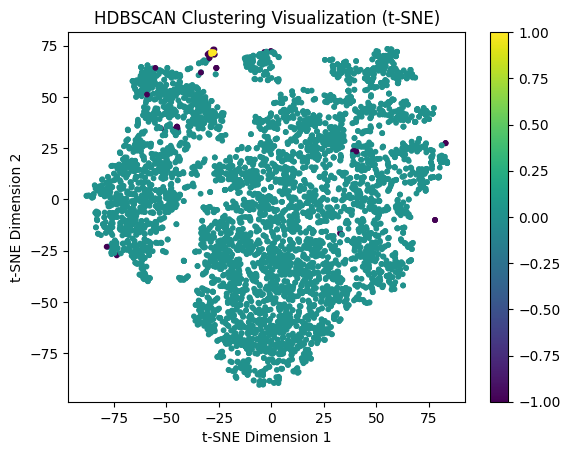

In [9]:
hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=10)
hdbscan_labels = hdbscan_model.fit_predict(X_scaled)

# Compute metrics and visualize
silhouette, davies_bouldin, calinski_harabasz = compute_metrics(X_scaled, hdbscan_labels, "HDBSCAN")
visualize_clusters_pca(X_scaled, hdbscan_labels, "HDBSCAN")
visualize_clusters_tsne(X_scaled, hdbscan_labels, "HDBSCAN")

results["Algorithm"].append("HDBSCAN")
results["Silhouette Score"].append(silhouette)
results["Davies-Bouldin Index"].append(davies_bouldin)
results["Calinski-Harabasz Score"].append(calinski_harabasz)

**4.4 Mean Shift Clustering**

Mean Shift Metrics:
  Silhouette Score: 0.28029064018903094
  Davies-Bouldin Index: 0.7519281235377548
  Calinski-Harabasz Score: 71.23013637696071


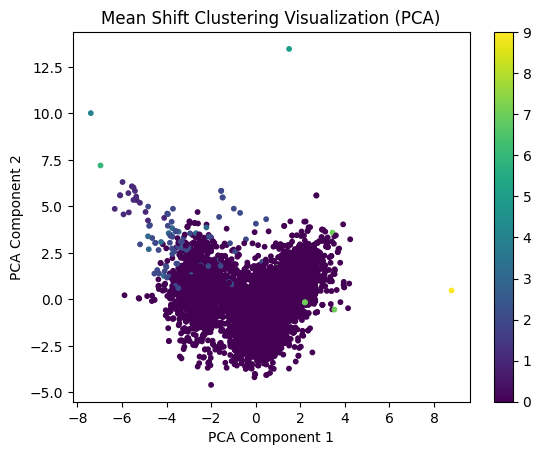

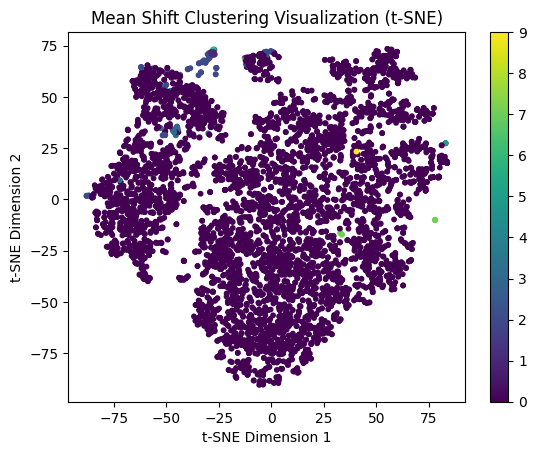

In [10]:
mean_shift = MeanShift()
mean_shift_labels = mean_shift.fit_predict(X_scaled)

# Compute metrics and visualize
silhouette, davies_bouldin, calinski_harabasz = compute_metrics(X_scaled, mean_shift_labels, "Mean Shift")
visualize_clusters_pca(X_scaled, mean_shift_labels, "Mean Shift")
visualize_clusters_tsne(X_scaled, mean_shift_labels, "Mean Shift")

results["Algorithm"].append("Mean Shift")
results["Silhouette Score"].append(silhouette)
results["Davies-Bouldin Index"].append(davies_bouldin)
results["Calinski-Harabasz Score"].append(calinski_harabasz)

**4.5: Hierarchical Clustering**

Hierarchical Clustering Metrics:
  Silhouette Score: 0.2004738779042242
  Davies-Bouldin Index: 1.601880085393253
  Calinski-Harabasz Score: 1487.2324858992092


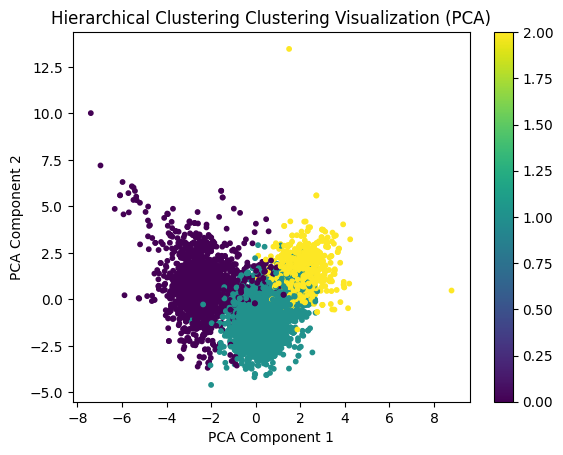

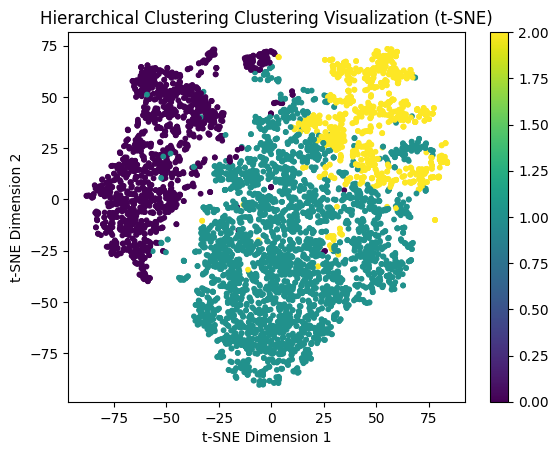

In [11]:
hierarchical = AgglomerativeClustering(n_clusters=3)
hierarchical_labels = hierarchical.fit_predict(X_scaled)

# Compute metrics and visualize
silhouette, davies_bouldin, calinski_harabasz = compute_metrics(X_scaled, hierarchical_labels, "Hierarchical Clustering")
visualize_clusters_pca(X_scaled, hierarchical_labels, "Hierarchical Clustering")
visualize_clusters_tsne(X_scaled, hierarchical_labels, "Hierarchical Clustering")

results["Algorithm"].append("Hierarchical Clustering")
results["Silhouette Score"].append(silhouette)
results["Davies-Bouldin Index"].append(davies_bouldin)
results["Calinski-Harabasz Score"].append(calinski_harabasz)

**4.6: Spectral Clustering (Optional)**

Spectral Clustering Metrics:
  Silhouette Score: 0.23030443340301884
  Davies-Bouldin Index: 1.5005619047941774
  Calinski-Harabasz Score: 1768.4850571696822


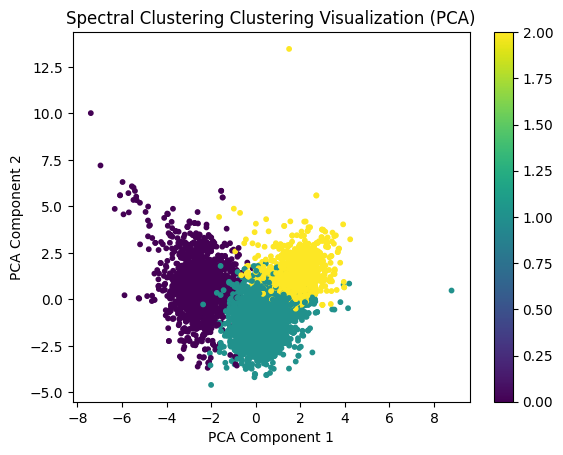

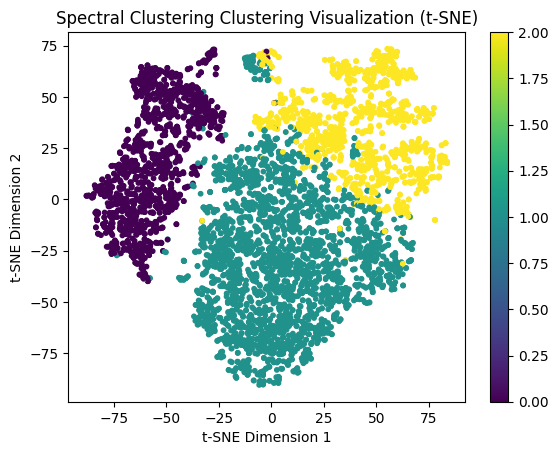

In [12]:
spectral = SpectralClustering(n_clusters=3, affinity='nearest_neighbors', random_state=42)
spectral_labels = spectral.fit_predict(X_scaled)

# Compute metrics and visualize
silhouette, davies_bouldin, calinski_harabasz = compute_metrics(X_scaled, spectral_labels, "Spectral Clustering")
visualize_clusters_pca(X_scaled, spectral_labels, "Spectral Clustering")
visualize_clusters_tsne(X_scaled, spectral_labels, "Spectral Clustering")

results["Algorithm"].append("Spectral Clustering")
results["Silhouette Score"].append(silhouette)
results["Davies-Bouldin Index"].append(davies_bouldin)
results["Calinski-Harabasz Score"].append(calinski_harabasz)

### Section 5: Comparison and Summary

In [14]:
# Convert results dictionary to DataFrame
comparison_df = pd.DataFrame(results)

# Display the results
print("Clustering Algorithm Comparison:")
print(comparison_df)

Clustering Algorithm Comparison:
                 Algorithm  Silhouette Score  Davies-Bouldin Index  \
0                  K-Means          0.235071              1.484034   
1                   DBSCAN         -0.452671              1.156521   
2                  HDBSCAN          0.545740              1.761970   
3               Mean Shift          0.280291              0.751928   
4  Hierarchical Clustering          0.200474              1.601880   
5      Spectral Clustering          0.230304              1.500562   

   Calinski-Harabasz Score  
0              1844.457339  
1                 5.852493  
2               136.852231  
3                71.230136  
4              1487.232486  
5              1768.485057  
